## Network Topologies

OptiWindNet supports three electrical topologies:

- **Branched:** a forest of rooted trees; terminals may have any number of neighbors.
- **Radial:** a collection of root-to-leaf paths; each terminal has at most two neighbors.
- **Ringed:** a collection of cyclic paths (multi-terminal *"loops"*), each including one or two roots (roots are implicitly neighboring each other). Only roots may belong to more than one path. Each terminal has exactly two neighbors. Single-terminal cycles degenerate to a single link. Each cycle has a link with `load=0` which splits the ring at its mid-point. `capacity` is the feeder limit of the split ring, so a ring can hold up to `2 * capacity` terminals.

> Attention: The term **topology** is also used to refer to the solution topology `S`. In the latter context, it means that S is just the connection-level network representation, not including the geometric details of the cable routes.

### Topologies, routesets, and validation

A topology `S` describes the electrical parent–child relations. `G_from_S(S, A)` gives the corresponding tentative physical graph. A routeset is the graph after routing, e.g. with `PathFinder(...).create_detours()`.

When working with the advanced API, validate each representation at the boundary where it is created. `describe_G()` provides a compact diagnostic summary that is useful alongside a plot.

In [1]:
from optiwindnet.importer import load_repository
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.svg import svgplot
from optiwindnet.heuristics import constructor
from optiwindnet.MILP import ModelOptions, solver_factory
from optiwindnet.interarraylib import describe_G, validate_routeset, validate_topology

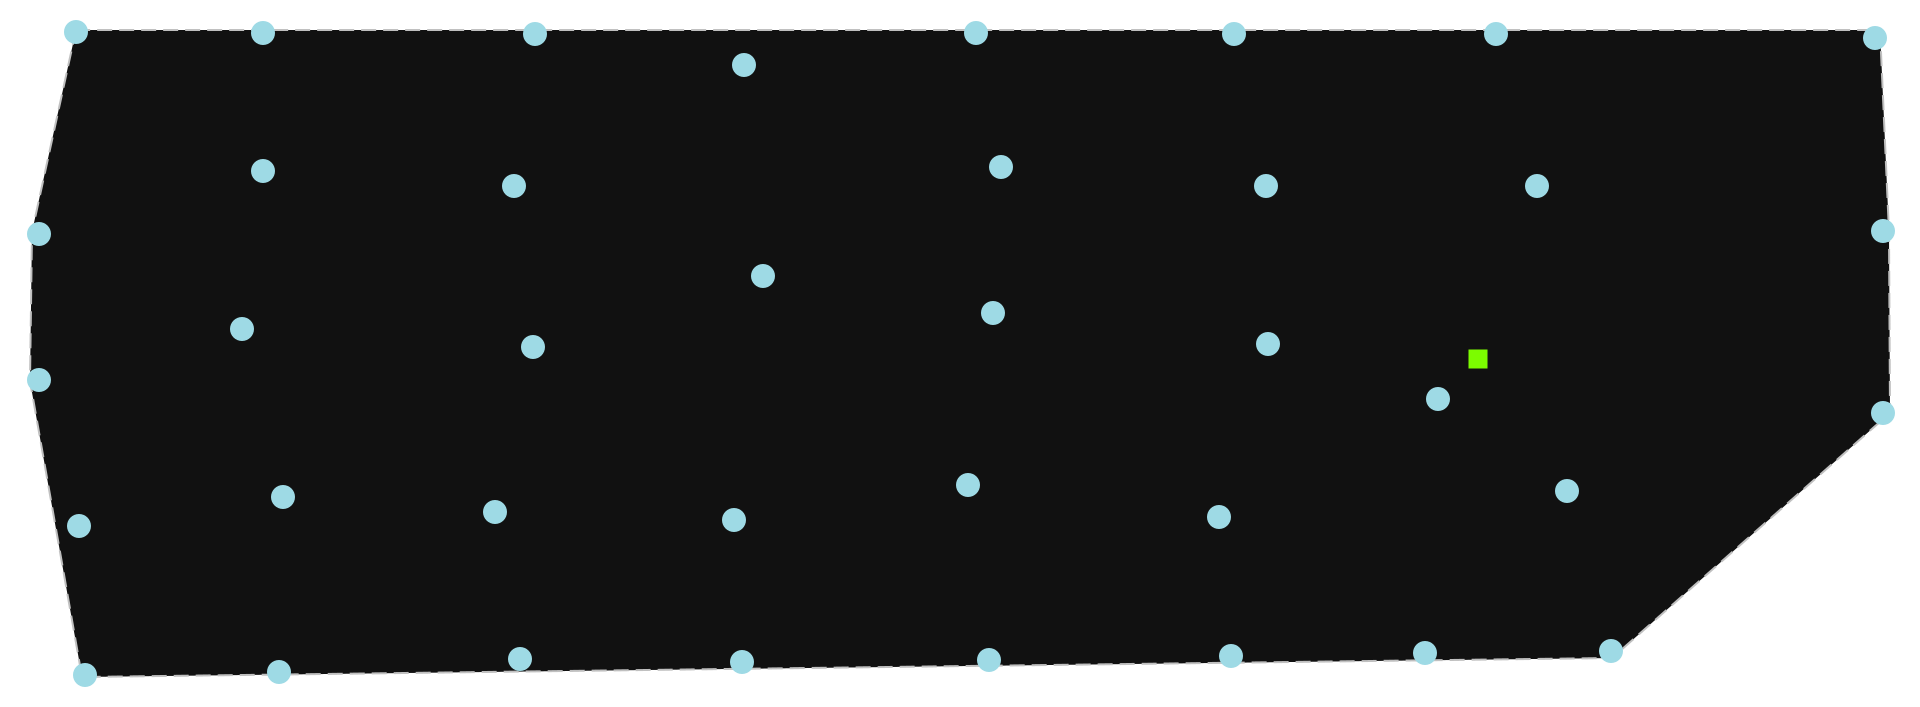

In [2]:
locations = load_repository()
L = locations.kaskasi
P, A = make_planar_embedding(L)
capacity = 5
svgplot(L)

In [3]:
solver = solver_factory('highs')

### The three topology types

The following cell is deliberately shared by the solver examples below: it plots the tentative physical graph corresponding to each topology. The link geometry is still direct at this stage.

### Warm-starts

`constructor()` can generate warmstarts for all three topology types through `method`.

In [4]:
S_branched = constructor(A, capacity=capacity, method='rootlust')

In [5]:
S_radial = constructor(A, capacity=capacity, method='radial_EW')

In [6]:
S_ring = constructor(A, capacity=capacity, method='ringed')

Function `validate_topology()` may be used to check if a solution is feasible from the electrical perspective.

In [7]:
validate_topology(S_ring)

[]

### Branched

In [8]:
# branched
solver.set_problem(P, A, capacity, model_options=ModelOptions(), warmstart=S_branched)
solver.solve(time_limit=30, mip_gap=1e-3)

SolutionInfo(runtime=30.010845184326172, bound=36688.03385242913, objective=37816.911975099436, relgap=0.029851144996017043, termination='maxTimeLimit')

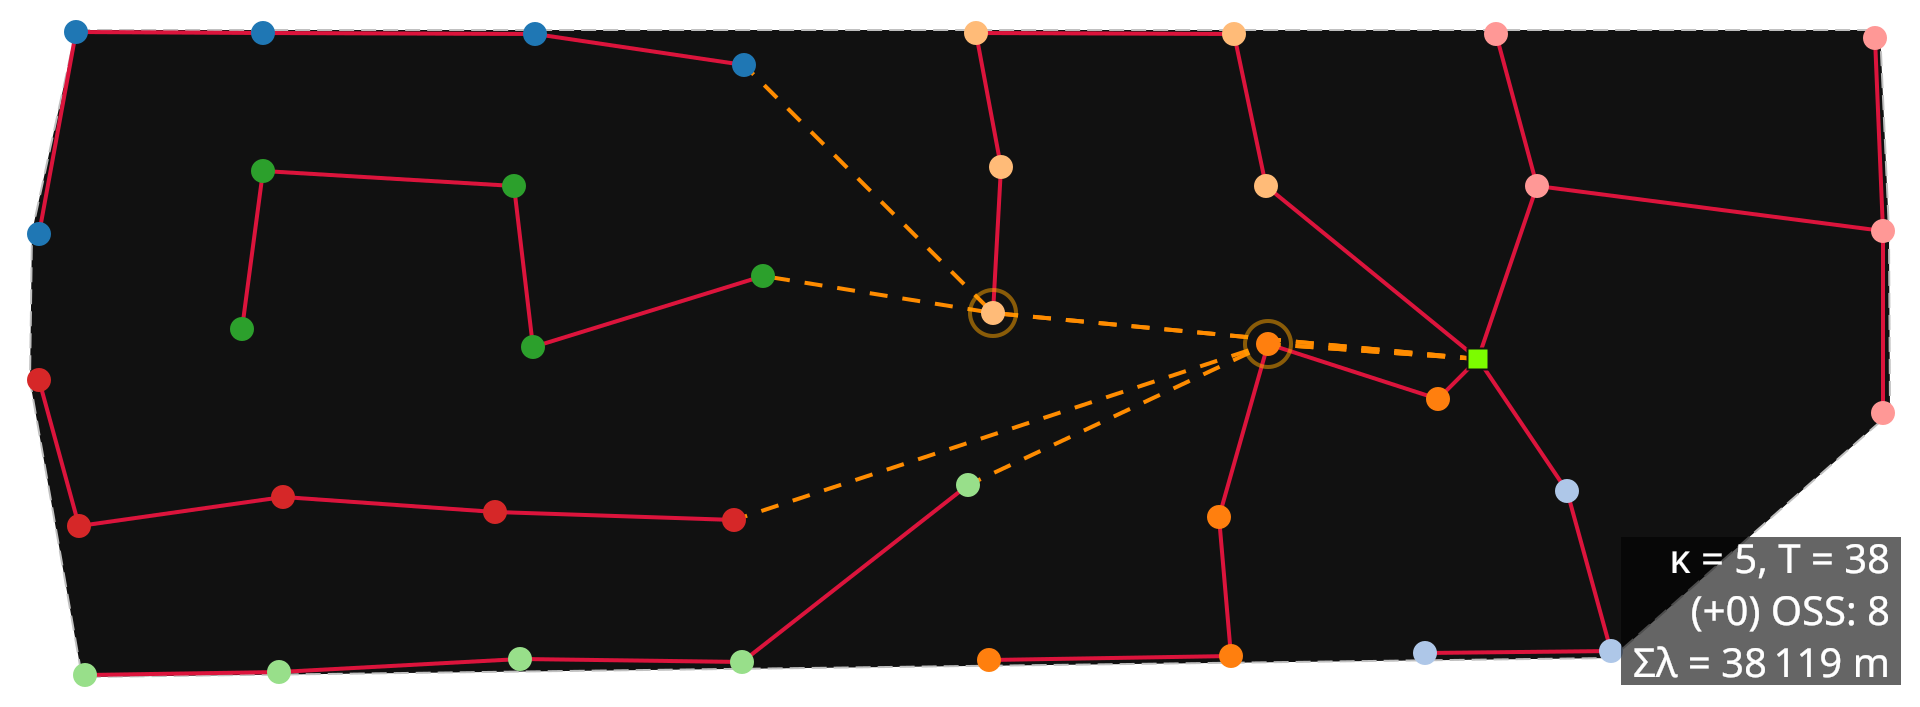

In [9]:
S, G = solver.get_solution()
svgplot(G)

### Radial

In [10]:
# radial
solver.set_problem(P, A, capacity, model_options=ModelOptions(topology='radial'), warmstart=S_radial)
solver.solve(time_limit=30, mip_gap=1e-3)

SolutionInfo(runtime=30.016808032989502, bound=37060.99661553814, objective=37911.327005923136, relgap=0.022429454665412907, termination='maxTimeLimit')

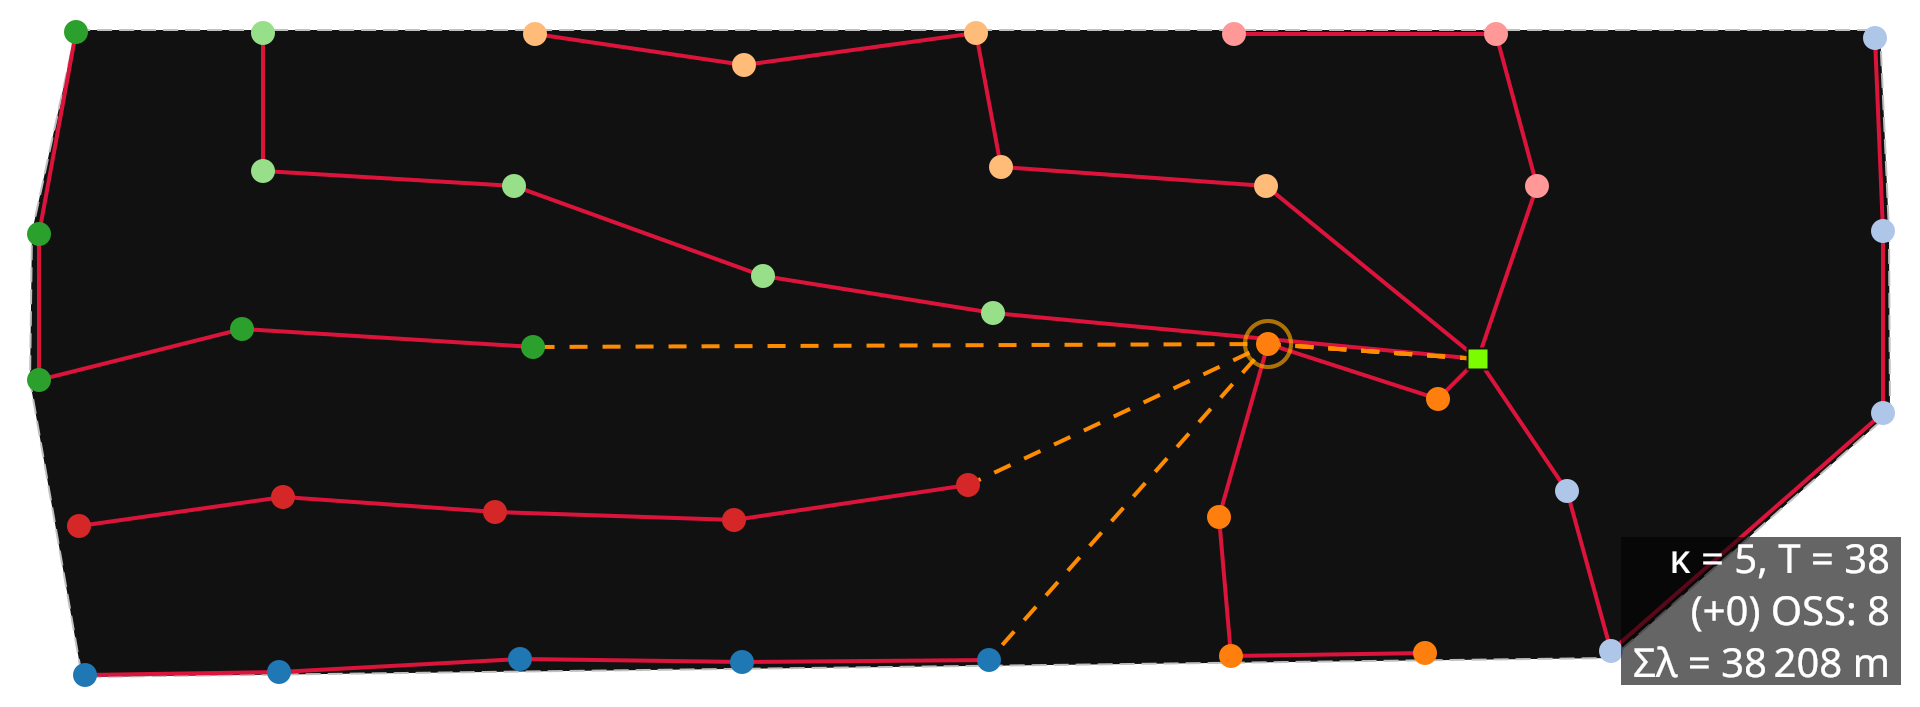

In [11]:
S, G = solver.get_solution()
svgplot(G)

### Ringed

In [12]:
# ringed
solver.set_problem(P, A, capacity, model_options=ModelOptions(topology='ringed'), warmstart=S_ring)
solver.solve(time_limit=60, mip_gap=1e-3)

SolutionInfo(runtime=60.01727795600891, bound=39898.47982086679, objective=42992.10955420628, relgap=0.07195808173681062, termination='maxTimeLimit')

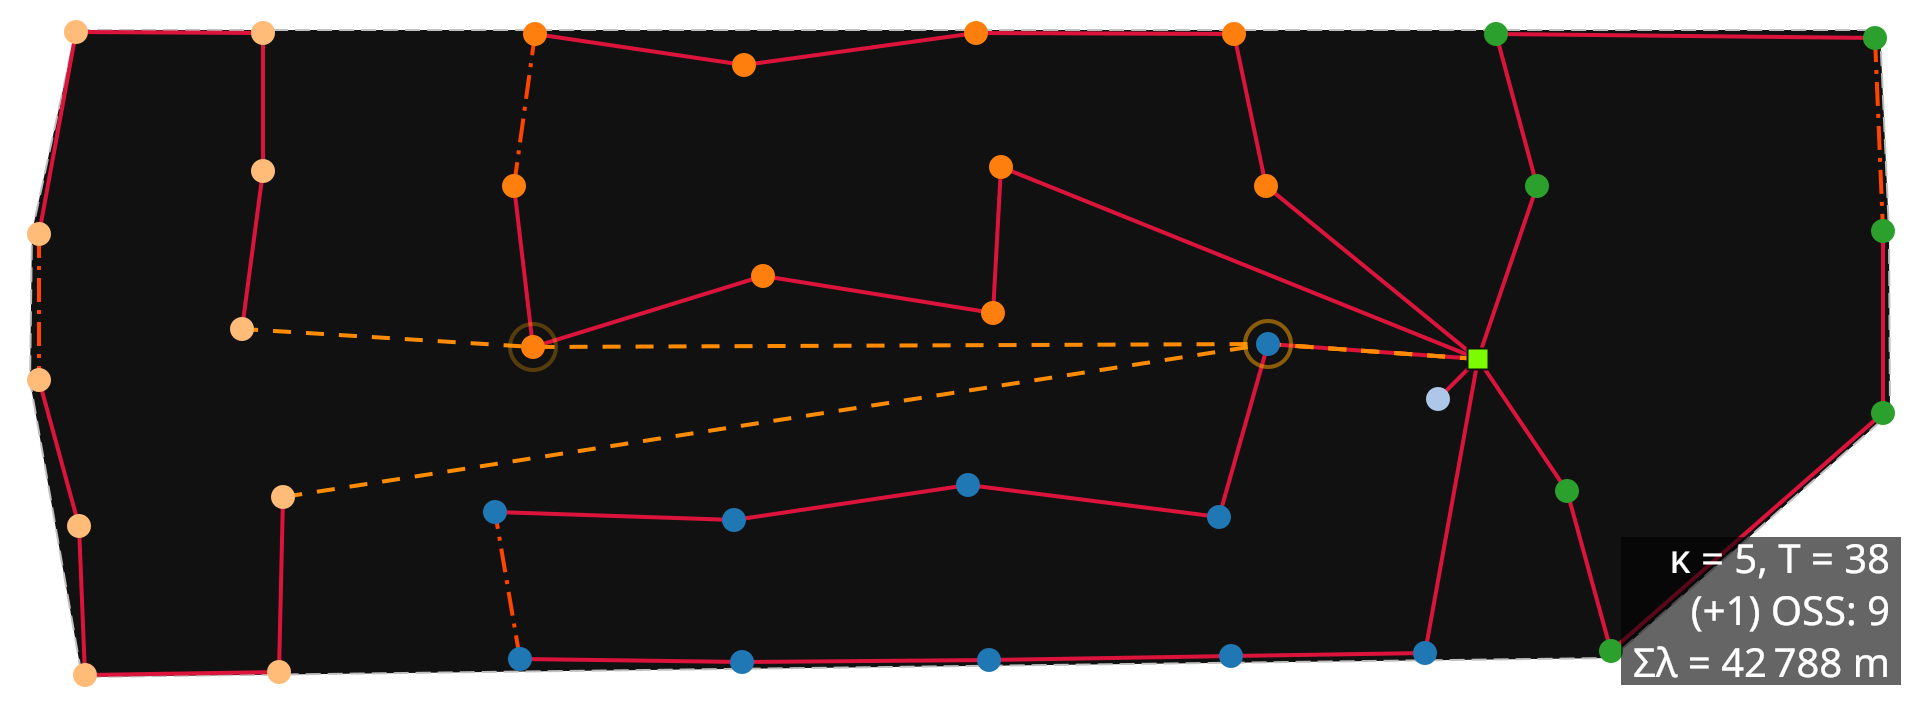

In [13]:
S, G = solver.get_solution()
svgplot(G)

Function `validate_routeset()` may be used to check if a routeset is correct (it calls `validate_topology()` internally).

In [14]:
validate_routeset(G)

[]